In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import re

from IPython.display import Markdown

In [2]:
base_path='shadow/examples/docs/tor-zkp-testB/shadow.data'
data = []

# Match all files regardless of extension
files = glob.glob(os.path.join(base_path, '**/*'), recursive=True)
    
for file in files:
    if os.path.isfile(file):
        with open(file, 'r', errors='ignore') as f:
            for line in f:
                data.append({'message': line.strip()})
                
df = pd.DataFrame(data)

In [11]:
# Define custom ZKP/Tor metrics mapping
metrics = {
    "Total Verification Rounds": r"Starting 20-Round FFS-ZKP Verification",
    "Verifier Connections": r"Connection received",
    "Verifier Successes": r"All rounds verified",
    "Verifier Rejections": r"Cheating detected",
    "Tor Stream Successes": r"FFS-ZKP handshake successful",
    "Tor Stream Failures": r"FFS-ZKP handshake failed|ZKP failed|handshake failed"    
}

report = []
for label, pattern in metrics.items():
    # Count occurrences by searching the entire shadow.data directory
    count = df['message'].str.contains(pattern, regex=True, na=False).sum()
    report.append({"Metric": label, "Count": count})

In [10]:
# Path to the hosts directory
hosts_dir = f"{base_path}/hosts/"

# Count nodes by role
nodes = os.listdir(hosts_dir)
counts = {
    "Clients": len([n for n in nodes if 'client' in n]),
    "Relays": len([n for n in nodes if 'relay' in n]),
    "Exits": len([n for n in nodes if 'exit' in n]),
    "Verifier": len([n for n in nodes if 'verifier' in n])
}

print("Simulated Architecture:")
for role, count in counts.items():
    print(f"- {role:<10}: {count}")

print("\nCircuits from each torclient:", (int)(report[0]['Count']/(counts["Clients"]-1)))

Simulated Architecture:
- Clients   : 201
- Relays    : 20
- Exits     : 4
- Verifier  : 1

Circuits from each torclient: 5


In [12]:
summary_df = pd.DataFrame(report)
summary_df.loc[len(summary_df)] = ["Verification Success Rate (%)", (summary_df.loc[1, 'Count'] / summary_df.loc[0, 'Count'] * 100).round(2)]

tmp_df = summary_df
tmp_df.set_index("Metric", inplace=True)

display(Markdown(tmp_df.round(2).to_markdown()))

| Metric                        |   Count |
|:------------------------------|--------:|
| Total Verification Rounds     |    1000 |
| Verifier Connections          |    1000 |
| Verifier Successes            |     998 |
| Verifier Rejections           |       2 |
| Tor Stream Successes          |     998 |
| Tor Stream Failures           |       2 |
| Verification Success Rate (%) |     100 |

In [5]:
def to_ms(ts_str):
    """ Extract timestamps, assumes format HH:MM:SS.mmm """
    h, m, s = ts_str.split(':')
    return (int(h)*3600 + int(m)*60 + float(s)) * 1000

In [6]:
# Load only output data
out_files = glob.glob(os.path.join(base_path, '**/*.stdout'), recursive=True)

out_data = []
time_regex = re.compile(r'Jan 01 (\d{2}:\d{2}:\d{2}\.\d{3})')

for file in out_files:
    with open(file, 'r', errors='ignore') as f:
        for line in f:
            match = time_regex.search(line)
            if match:
                out_data.append({
                    'timestamp': match.group(1),
                    'message': line.strip()
                })

out_df = pd.DataFrame(out_data)

# Calculate Latency
out_df['time_ms'] = out_df['timestamp'].apply(to_ms)
start_times = out_df[out_df['message'].str.contains('Received START chunk')].sort_values('time_ms')['time_ms'].values
end_times = out_df[out_df['message'].str.contains('FFS-ZKP handshake successful')].sort_values('time_ms')['time_ms'].values

min_len = min(len(start_times), len(end_times))
latencies = end_times[:min_len] - start_times[:min_len]

# Total Duration (in seconds)
total_duration = (out_df['time_ms'].max() - out_df['time_ms'].min()) / 1000

# Throughput (HPS)
hps = len(out_df[out_df['message'].str.contains('handshake successful')]) / total_duration

# Failure Detection Rate
detected_failures = df['message'].str.contains('Cheating detected|ZKP failed', regex=True).sum()
total_attempts = df['message'].str.contains('Starting 20-Round FFS-ZKP').sum()
failure_detection_rate = (detected_failures / total_attempts * 100) if total_attempts > 0 else 0


In [7]:
# Consolidate ALL metrics into one dictionary
# Use the string names instead of numerical indices 1 and 0
performance_data = {
    "Verification Success Rate (%)": (
        summary_df.loc["Verifier Successes", 'Count'] / 
        summary_df.loc["Verifier Connections", 'Count'] * 100
    ).round(2),
    "Average Latency (ms)": latencies.mean(),
    "Jitter (Std Dev ms)": latencies.std(),
    "Throughput (HPS)": hps,
    "Failure Detection Rate (%)": failure_detection_rate
}

dashboard_df = pd.DataFrame(performance_data.items(), columns=["Metric", "Value"])
dashboard_df.set_index("Metric", inplace=True)

display(Markdown(dashboard_df.round(2).to_markdown()))

| Metric                        |   Value |
|:------------------------------|--------:|
| Verification Success Rate (%) |   99.8  |
| Average Latency (ms)          |  431.94 |
| Jitter (Std Dev ms)           |  368.35 |
| Throughput (HPS)              |    0.14 |
| Failure Detection Rate (%)    |    0.2  |

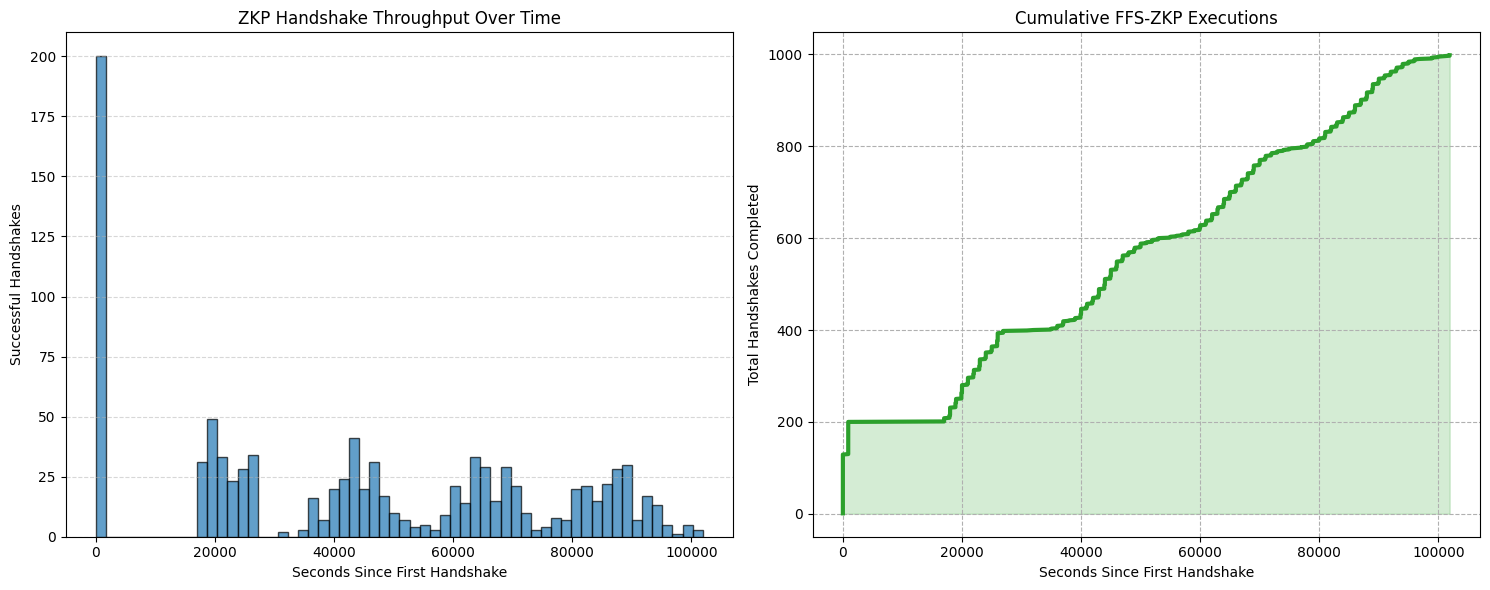

In [8]:
timestamps = out_df[out_df['message'].str.contains('FFS-ZKP handshake successful')]['time_ms'].tolist()
timestamps.sort()
start_time = timestamps[0]
normalized_times = [t - start_time for t in timestamps]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Handshake Throughput Histogram
axes[0].hist(normalized_times, bins=60, color='#1f77b4', edgecolor='black', alpha=0.7)
axes[0].set_title('ZKP Handshake Throughput Over Time')
axes[0].set_xlabel('Seconds Since First Handshake')
axes[0].set_ylabel('Successful Handshakes')
axes[0].grid(axis='y', alpha=0.5, linestyle='--')

# Cumulative FFS-ZKP Executions
axes[1].plot(normalized_times, range(1, len(normalized_times) + 1), color='#2ca02c', linewidth=3)
axes[1].fill_between(normalized_times, range(1, len(normalized_times) + 1), color='#2ca02c', alpha=0.2)
axes[1].set_title('Cumulative FFS-ZKP Executions')
axes[1].set_xlabel('Seconds Since First Handshake')
axes[1].set_ylabel('Total Handshakes Completed')
axes[1].grid(True, linestyle='--')

plt.tight_layout()
plt.show()

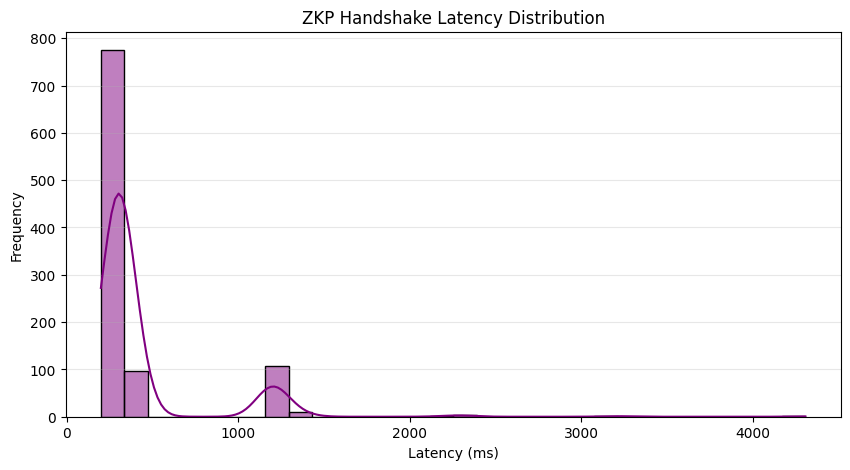

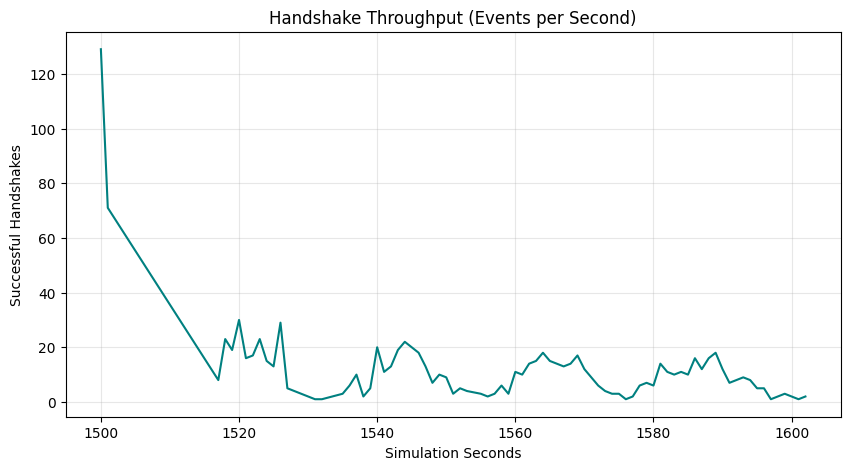

In [9]:
# Latency Distribution
plt.figure(figsize=(10, 5))
sns.histplot(latencies, bins=30, kde=True, color='purple')
plt.title('ZKP Handshake Latency Distribution')
plt.xlabel('Latency (ms)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Throughput Stability
plt.figure(figsize=(10, 5))
out_df['sec'] = (out_df['time_ms'] / 1000).astype(int)
throughput = out_df[out_df['message'].str.contains('handshake successful')].groupby('sec').size()
throughput.plot(kind='line', color='teal')
plt.title('Handshake Throughput (Events per Second)')
plt.xlabel('Simulation Seconds')
plt.ylabel('Successful Handshakes')
plt.grid(True, alpha=0.3)
plt.show()